# 02 - Baseline NNUE Training

Train a standard NNUE (marlinflow-style NnBoard768) as the control baseline.

**Architecture**: `768 -> ft(128) -> CReLU -> concat(stm, nstm) -> out(256 -> 1) -> sigmoid`

**Checkpoints and logs saved to Google Drive** so we can resume across sessions.

---

## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
os.environ['PATH'] = f"/root/.cargo/bin:{os.environ['PATH']}"

# Clone/update repo
if not os.path.exists('/content/kanue'):
    !git clone --depth 1 https://github.com/y0sif/kanue.git /content/kanue
else:
    !cd /content/kanue && git pull -q

# Build native feature extractor (~10s, zero dependencies)
NATIVE_LIB = '/content/kanue/crates/kanue-parse/target/release/libkanue_parse.so'
if not os.path.exists(NATIVE_LIB):
    if not os.path.exists('/root/.cargo/bin/cargo'):
        !curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh -s -- -y 2>&1 | tail -1
    !cd /content/kanue/crates/kanue-parse && cargo build --release 2>&1 | tail -3

# Clear stale module cache and add source path
for key in list(sys.modules.keys()):
    if 'kanue' in key:
        del sys.modules[key]
sys.path.insert(0, '/content/kanue/src')
!pip install -q python-chess tqdm

Mounted at /content/drive
Cloning into '/content/kanue'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 50 (delta 1), reused 34 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 80.06 KiB | 5.72 MiB/s, done.
Resolving deltas: 100% (1/1), done.
source "$HOME/.cargo/env.xsh"   # For xonsh
   Compiling kanue-parse v0.1.0 (/content/kanue/crates/kanue-parse)
    Finished `release` profile [optimized] target(s) in 0.22s
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 57.6 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done


In [2]:
import torch
import numpy as np
from pathlib import Path

from kanue.models import NnBoard768
from kanue.data.native import NativeBatchLoader
from kanue.utils import DriveCheckpointer, train_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')

Device: cuda
GPU: Tesla T4


## 1. Load Data from Drive

Uses `NativeBatchLoader` -- compiled Rust feature extraction via ctypes.
Memory-maps the bulletformat file and extracts Board768 features in native code.

In [3]:
DATA_DIR = Path('/content/drive/MyDrive/kanue/data')
BATCH_SIZE = 16384

train_loader = NativeBatchLoader(
    DATA_DIR / 'train.data', batch_size=BATCH_SIZE, shuffle=True, device=device
)
val_loader = NativeBatchLoader(
    DATA_DIR / 'val.data', batch_size=BATCH_SIZE, shuffle=False, device=device
)

print(f'Train: {train_loader.n_positions:,} positions ({len(train_loader)} batches)')
print(f'Val:   {val_loader.n_positions:,} positions ({len(val_loader)} batches)')

Train: 8,000,000 positions (489 batches)
Val:   1,000,000 positions (62 batches)


## 2. Define Baseline Model

In [4]:
HIDDEN_SIZE = 128

model = NnBoard768(hidden_size=HIDDEN_SIZE).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model: NnBoard768(hidden={HIDDEN_SIZE})')
print(f'Total parameters: {total_params:,}')
print()
print(model)

Model: NnBoard768(hidden=128)
Total parameters: 98,689

NnBoard768(
  (ft): Linear(in_features=768, out_features=128, bias=True)
  (out): Linear(in_features=256, out_features=1, bias=True)
)


## 3. Train

In [8]:
EPOCHS = 50
LR = 1e-3
LR_DROP_EPOCH = 35
CHECKPOINT_EVERY = 5

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
checkpointer = DriveCheckpointer('baseline')

log = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    checkpointer=checkpointer,
    checkpoint_every=CHECKPOINT_EVERY,
    lr_drop_epoch=LR_DROP_EPOCH,
)

print(f'\nBest val loss: {min(log["val_loss"]):.6f}')
print(f'Best val accuracy: {max(log["val_accuracy"]):.4f}')

Epoch   0 | train_loss=0.027847 | val_loss=0.024556 | val_acc=0.6923 | 13.4s


Epoch   1 | train_loss=0.023569 | val_loss=0.022589 | val_acc=0.7166 | 2.1s


Epoch   2 | train_loss=0.021943 | val_loss=0.021375 | val_acc=0.7271 | 2.1s


Epoch   3 | train_loss=0.021157 | val_loss=0.020654 | val_acc=0.7344 | 2.1s


Epoch   4 | train_loss=0.020632 | val_loss=0.019992 | val_acc=0.7395 | 2.1s


...

Epoch  45 | train_loss=0.015324 | val_loss=0.015137 | val_acc=0.7861 | 2.0s


Epoch  46 | train_loss=0.015083 | val_loss=0.015135 | val_acc=0.7854 | 2.0s


Epoch  47 | train_loss=0.015099 | val_loss=0.015120 | val_acc=0.7880 | 2.0s


Epoch  48 | train_loss=0.015103 | val_loss=0.015122 | val_acc=0.7872 | 2.0s


Epoch  49 | train_loss=0.015110 | val_loss=0.015118 | val_acc=0.7879 | 2.0s

Best val loss: 0.015118
Best val accuracy: 0.7885


## 4. Training Curves

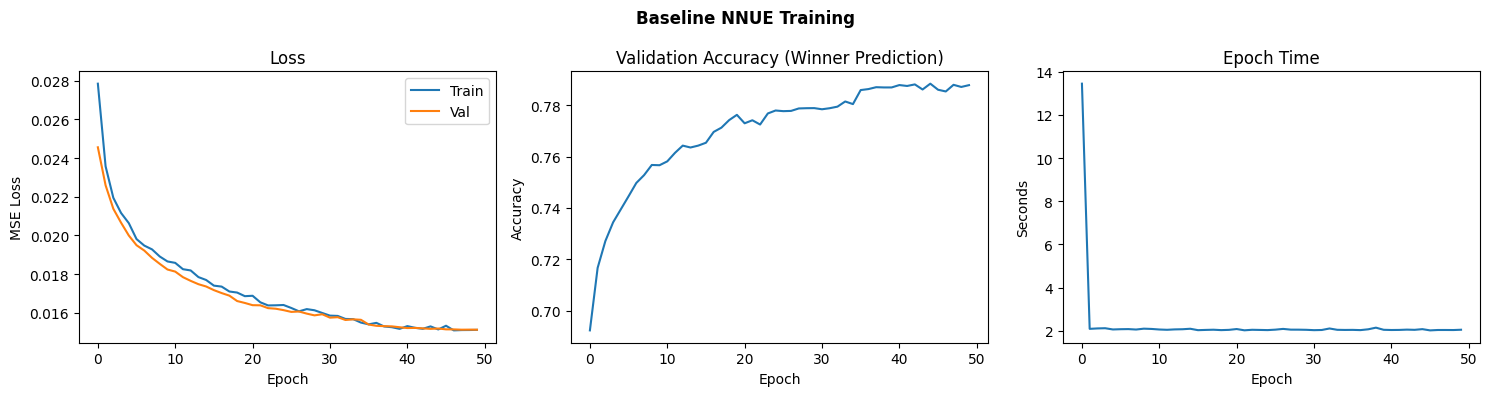

Baseline training complete. Proceed to notebook 03.


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(len(log['train_loss']))

axes[0].plot(epochs, log['train_loss'], label='Train')
axes[0].plot(epochs, log['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs, log['val_accuracy'])
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy (Winner Prediction)')

axes[2].plot(epochs, log['epoch_time'])
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Seconds')
axes[2].set_title('Epoch Time')

plt.suptitle('Baseline NNUE Training', fontweight='bold')
plt.tight_layout()

results_dir = Path('/content/drive/MyDrive/kanue/results')
plt.savefig(str(results_dir / 'baseline_training.png'), dpi=150)
plt.show()

print('Baseline training complete. Proceed to notebook 03.')